# 02 — Two-Spin Dynamics

Sakurai Chapter 2: Quantum dynamics

Jo–Kim paper: Equation (8), Figure 1

Our learning sequence

Construct and understand the Hamiltonian.

Calculate exact time evolution using U(t)=e^
−iHt
.

Calculate and plot the time-dependent magnetisation.
Investigate energy conservation and the emergence of entanglement.

2.1 Construct the two-spin transverse-field Ising Hamiltonian using NumPy and verify that it is Hermitian.

In [24]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

J = 1.0
Delta = 1.0

sigma_x = np.array([
    [0, 1],
    [1, 0]
], dtype=complex)

sigma_y = np.array([
    [0, -1j],
    [1j, 0]
], dtype=complex)

sigma_z = np.array([
    [1, 0],
    [0, -1]
], dtype=complex)

I = np.eye(2, dtype=complex)

sx1 = np.kron(sigma_x, I)
sx2 = np.kron(I, sigma_x)

sy1 = np.kron(sigma_y, I)
sy2 = np.kron(I, sigma_y)

sz1 = np.kron(sigma_z, I)
sz2 = np.kron(I, sigma_z)

H_interaction = -J * (sz1 @ sz2)    # Interaction term

H_field = Delta * (sx1 + sx2)   # Transverse field term

H = H_interaction + H_field

print("Hamiltonian:")
print(H)

print("Hamiltonian shape:", H.shape)
print("Hermitian:", np.allclose(H, H.conj().T)) #check for Hermitian property
  

Hamiltonian:
[[-1.+0.j  1.+0.j  1.+0.j  0.+0.j]
 [ 1.+0.j  1.+0.j  0.+0.j  1.+0.j]
 [ 1.+0.j  0.+0.j  1.+0.j  1.+0.j]
 [ 0.+0.j  1.+0.j  1.+0.j -1.+0.j]]
Hamiltonian shape: (4, 4)
Hermitian: True


2.2 Construct the initial two-spin state and determine whether it is an eigenstate of the full Hamiltonian.

In [16]:

up = np.array([1, 0], dtype=complex)

psi0 = np.kron(up, up)

Hpsi0 = H @ psi0

print("Initial state:", psi0)
print("H acting on initial state:", Hpsi0)
  

Initial state: [1.+0.j 0.+0.j 0.+0.j 0.+0.j]
H acting on initial state: [-1.+0.j  1.+0.j  1.+0.j  0.+0.j]


2.3 Calculate the time evolution of the initial state using the matrix exponential and verify unitarity, state normalisation and magnetisation.

In [25]:

t = 0.5

U = expm(-1j * H * t)

psi_t = U @ psi0

print("State at t = 0.5:")
print(psi_t)


# Check that U is unitary
print(np.allclose(U.conj().T @ U, np.eye(4)))

# Check for nomalization
norm = np.vdot(psi_t, psi_t)

print("Norm:", norm)

Mz = (sz1 + sz2) / 2

# Use psi_t to calculate the expectation value
magnetisation = np.vdot(psi_t, Mz @ psi_t)

print("Magnetisation:", magnetisation)


State at t = 0.5:
[ 6.57516886e-01+0.44078943j  2.77555756e-17-0.40215331j
 -3.98986399e-17-0.40215331j -2.20065676e-01-0.03863611j]
True
Norm: (0.9999999999999998+0j)
Magnetisation: (0.5767021231946339+0j)


2.4 Simulate the exact time evolution over a range of time points and visualise the resulting magnetisation oscillations.

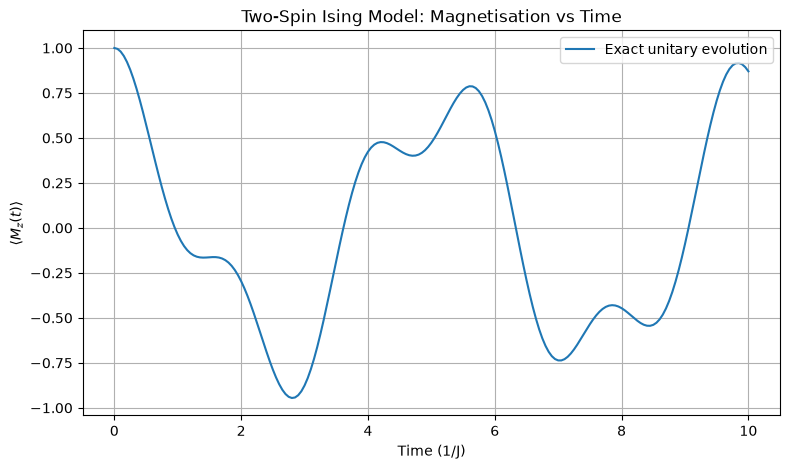

Time: 0.5
Magnetisation: 0.5767021231946339


In [20]:
times = np.linspace(0, 10, 201)

magnetisations = []

for t in times:
    U = expm(-1j * H * t)
    psi_t = U @ psi0

    expectation = np.vdot(psi_t, Mz @ psi_t)
    magnetisations.append(expectation.real)

plt.figure(figsize=(9, 5))
plt.plot(times, magnetisations, label="Exact unitary evolution")

plt.xlabel("Time (1/J)")
plt.ylabel(r"$\langle M_z(t) \rangle$")
plt.title("Two-Spin Ising Model: Magnetisation vs Time")

plt.grid(True)
plt.legend()
plt.show()


index = np.argmin(np.abs(times - 0.5))

print("Time:", times[index])
print("Magnetisation:", magnetisations[index])

In [21]:
eigenvalues, eigenvectors = np.linalg.eigh(H)

print("Energy eigenvalues:")
print(eigenvalues)

H_diagonal = eigenvectors.conj().T @ H @ eigenvectors

print("H in energy basis:")
print(np.round(H_diagonal, 10))

Energy eigenvalues:
[-2.23606798 -1.          1.          2.23606798]
H in energy basis:
[[-2.23606798+0.j -0.        +0.j  0.        +0.j -0.        +0.j]
 [-0.        +0.j -1.        +0.j  0.        +0.j  0.        +0.j]
 [ 0.        +0.j  0.        +0.j  1.        +0.j -0.        +0.j]
 [-0.        +0.j  0.        +0.j -0.        +0.j  2.23606798+0.j]]


2.5 The objective of this exercise is to understand the time evolution of our two-spin system through the energy eigenstates of its Hamiltonian.

We diagonalise the Hamiltonian to obtain its eigenvalues and eigenvectors, then express our initial state as a superposition of energy eigenstates. Each eigenstate acquires a different phase during time evolution, creating interference that produces oscillations in observable quantities such as magnetisation.

Finally, we verify that the expectation value of energy remains constant, as required for a closed quantum system with a time-independent Hamiltonian

Energy eigenvalues:
[-2.23606798 -1.          1.          2.23606798]

Hamiltonian in energy eigenbasis:
[[-2.236068+0.j -0.      +0.j  0.      +0.j -0.      +0.j]
 [-0.      +0.j -1.      +0.j  0.      +0.j  0.      +0.j]
 [ 0.      +0.j  0.      +0.j  1.      +0.j -0.      +0.j]
 [-0.      +0.j  0.      +0.j -0.      +0.j  2.236068+0.j]]

Diagonalisation successful: True

Energy eigenstate probabilities:
E = -2.236068, Probability = 0.361803
E = -1.000000, Probability = 0.500000
E = 1.000000, Probability = 0.000000
E = 2.236068, Probability = 0.138197

Total probability: 1.0

Initial energy: -1.0
Final energy: -0.999999999999999
Maximum energy deviation: 6.8833827526759706e-15


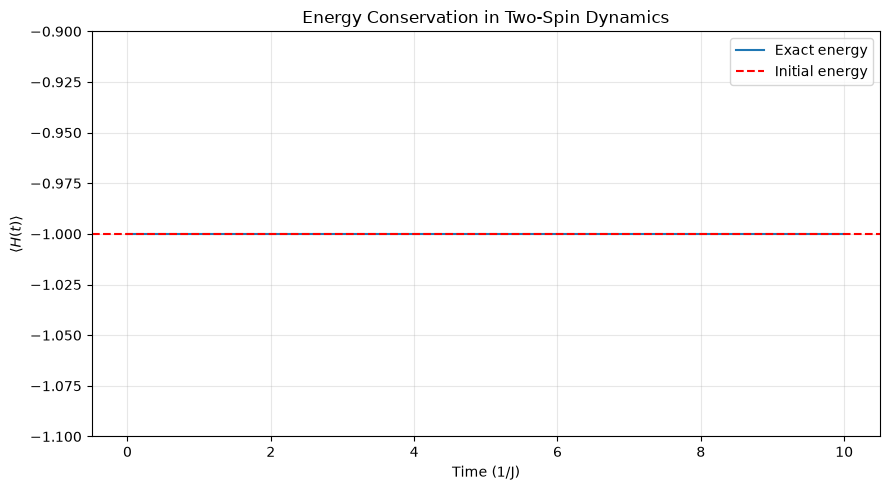

In [ ]:

# EXERCISE 2.5: ENERGY EIGENSTATES AND CONSERVATION

# --------------------------------------------------
# 1. Diagonalise the Hamiltonian
# --------------------------------------------------

eigenvalues, eigenvectors = np.linalg.eigh(H)

print("Energy eigenvalues:")
print(eigenvalues)

# Transform the Hamiltonian into its energy eigenbasis
H_diagonal = eigenvectors.conj().T @ H @ eigenvectors

print("\nHamiltonian in energy eigenbasis:")
print(np.round(H_diagonal, 6))

print("\nDiagonalisation successful:",
      np.allclose(H_diagonal, np.diag(eigenvalues)))


# --------------------------------------------------
# 2. Expand the initial state in the energy eigenbasis
# --------------------------------------------------

# c_n = <E_n|psi0>
coefficients = eigenvectors.conj().T @ psi0

# Probability of each energy eigenstate
probabilities = np.abs(coefficients)**2

print("\nEnergy eigenstate probabilities:")

for E, p in zip(eigenvalues, probabilities):
    print(f"E = {E:.6f}, Probability = {p:.6f}")

print("\nTotal probability:", np.sum(probabilities))


# --------------------------------------------------
# 3. Calculate energy throughout time evolution
# --------------------------------------------------

energies = []

for t in times:

    # Exact time-evolution operator
    U = expm(-1j * H * t)

    # Evolve the initial state
    psi_t = U @ psi0

    # Calculate the energy expectation value
    energy = np.vdot(psi_t, H @ psi_t)

    energies.append(energy.real)

energies = np.array(energies)

initial_energy = np.vdot(psi0, H @ psi0).real

print("\nInitial energy:", initial_energy)
print("Final energy:", energies[-1])
print("Maximum energy deviation:",
      np.max(np.abs(energies - initial_energy)))


# --------------------------------------------------
# 4. Plot energy conservation
# --------------------------------------------------

plt.figure(figsize=(9, 5))

plt.plot(times, energies, label="Exact energy")

plt.axhline(
    initial_energy,
    linestyle="--",
    color="red",
    label="Initial energy"
)

plt.xlabel("Time (1/J)")
plt.ylabel(r"$\langle H(t) \rangle$")
plt.title("Energy Conservation in Two-Spin Dynamics")

plt.ylim(initial_energy - 0.1, initial_energy + 0.1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

2.6 Calculate the reduced density matrix and purity of one spin, investigate how entanglement develops during unitary evolution, and verify our numerical implementation.

INITIAL CONDITIONS
Initial reduced purity: 1.0
Initial energy: -1.0

NUMERICAL VALIDATION
Maximum normalisation error: 3.552713678800501e-15
Maximum energy deviation: 6.8833827526759706e-15
Maximum difference between exact methods: 5.312959769856559e-15
Maximum difference between spin purities: 3.3306690738754696e-16

Magnetisation at t = 0.5: 0.5767021231946339
Minimum reduced purity: 0.5135698547051558

All validation checks passed.


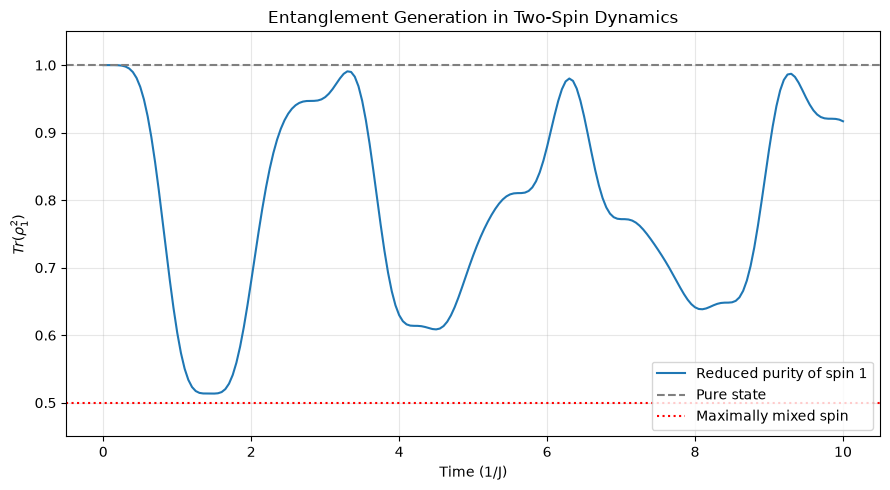

In [23]:

# EXERCISE 2.6: ENTANGLEMENT, PURITY AND VALIDATION

# --------------------------------------------------
# 1. Prepare the energy-basis expansion
# --------------------------------------------------

coefficients = eigenvectors.conj().T @ psi0

purities = []
magnetisations_26 = []
energies_26 = []
norms = []
evolution_errors = []
spin_purity_differences = []

initial_energy = np.vdot(psi0, H @ psi0).real


# --------------------------------------------------
# 2. Evolve the state and calculate observables
# --------------------------------------------------

for t in times:

    # Exact evolution using the matrix exponential
    U = expm(-1j * H * t)
    psi_t = U @ psi0

    # Independently calculate evolution in the energy basis
    phases = np.exp(-1j * eigenvalues * t)
    psi_eigen = eigenvectors @ (coefficients * phases)

    evolution_errors.append(
        np.linalg.norm(psi_t - psi_eigen)
    )

    # Check state normalisation
    norms.append(np.vdot(psi_t, psi_t).real)

    # Calculate magnetisation and energy
    magnetisations_26.append(
        np.vdot(psi_t, Mz @ psi_t).real
    )

    energies_26.append(
        np.vdot(psi_t, H @ psi_t).real
    )

    # --------------------------------------------------
    # 3. Construct the reduced density matrices
    # --------------------------------------------------

    # Reshape the four amplitudes into a 2x2 array.
    # Rows represent spin 1 and columns represent spin 2.
    A = psi_t.reshape(2, 2)

    # Trace out spin 2 to obtain the state of spin 1
    rho1 = A @ A.conj().T

    # Trace out spin 1 to obtain the state of spin 2
    rho2 = A.T @ A.conj()

    # Calculate the purity of both spins
    purity1 = np.trace(rho1 @ rho1).real
    purity2 = np.trace(rho2 @ rho2).real

    purities.append(purity1)
    spin_purity_differences.append(
        abs(purity1 - purity2)
    )


# --------------------------------------------------
# 4. Numerical validation
# --------------------------------------------------

purities = np.array(purities)
magnetisations_26 = np.array(magnetisations_26)
energies_26 = np.array(energies_26)

print("INITIAL CONDITIONS")
print("Initial reduced purity:", purities[0])
print("Initial energy:", initial_energy)

print("\nNUMERICAL VALIDATION")
print(
    "Maximum normalisation error:",
    np.max(np.abs(np.array(norms) - 1))
)

print(
    "Maximum energy deviation:",
    np.max(np.abs(energies_26 - initial_energy))
)

print(
    "Maximum difference between exact methods:",
    np.max(evolution_errors)
)

print(
    "Maximum difference between spin purities:",
    np.max(spin_purity_differences)
)

print(
    "\nMagnetisation at t = 0.5:",
    magnetisations_26[np.argmin(abs(times - 0.5))]
)

print("Minimum reduced purity:", np.min(purities))

assert np.allclose(norms, 1)
assert np.allclose(energies_26, initial_energy)
assert np.allclose(evolution_errors, 0, atol=1e-10)
assert np.allclose(spin_purity_differences, 0, atol=1e-10)
assert np.all((purities >= 0.5 - 1e-10) &
              (purities <= 1 + 1e-10))

print("\nAll validation checks passed.")


# --------------------------------------------------
# 5. Plot the reduced purity
# --------------------------------------------------

plt.figure(figsize=(9, 5))

plt.plot(
    times,
    purities,
    label="Reduced purity of spin 1"
)

plt.axhline(
    1,
    color="gray",
    linestyle="--",
    label="Pure state"
)

plt.axhline(
    0.5,
    color="red",
    linestyle=":",
    label="Maximally mixed spin"
)

plt.xlabel("Time (1/J)")
plt.ylabel(r"$Tr(\rho_1^2)$")
plt.title("Entanglement Generation in Two-Spin Dynamics")
plt.ylim(0.45, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()